# Boosted Tree Model

## Importing all train/test pickle files as well as cleaned data

In [36]:
import pickle as pk

df_cleaned = ''
with open(r"C:\Users\cover\Desktop\MISY331\Final Project\df_cleaned.pkl", 'rb') as file:
    df_cleaned = pk.load(file)

In [37]:
df_cleaned.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferredOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4,Phone,3,6,Debit Card,Female,3,3,Laptop & Accessory,2,Single,9,1,11,1,1,5,159.93
1,50002,1,3,Phone,1,8,Electronic Payment,Male,3,4,Mobile Phone,3,Single,7,1,15,0,1,0,120.90
2,50003,1,3,Phone,1,30,Debit Card,Male,2,4,Mobile Phone,3,Single,6,1,14,0,1,3,120.28
3,50004,1,0,Phone,3,15,Debit Card,Male,2,4,Laptop & Accessory,5,Single,8,0,23,0,1,3,134.07
4,50005,1,0,Phone,1,12,Credit Card,Male,3,3,Mobile Phone,5,Single,3,0,11,1,1,3,129.60


In [38]:
X_train = ''
with open(r"C:\Users\cover\Desktop\MISY331\Final Project\X_train.pkl", 'rb') as file:
    X_train = pk.load(file)

In [39]:
X_train.head()

,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,...,PreferredPaymentMode_Credit Card,PreferredPaymentMode_Debit Card,PreferredPaymentMode_Electronic Payment,Gender_Male,PreferredOrderCat_Grocery,PreferredOrderCat_Laptop & Accessory,PreferredOrderCat_Mobile Phone,PreferredOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
2901,4,1,7,3,5,3,3,0,23,3,...,0,1,0,1,0,0,0,0,0,1
1450,30,2,8,2,4,1,10,0,21,0,...,0,0,1,0,0,0,0,1,1,0
2437,3,1,34,3,3,1,5,0,20,1,...,0,0,0,1,0,0,1,0,1,0
4027,2,3,10,4,4,4,3,0,20,2,...,1,0,0,0,0,0,1,0,1,0
362,0,1,6,3,4,4,2,0,13,1,...,0,1,0,0,0,0,1,0,0,1


In [40]:
X_test = ''
with open(r"C:\Users\cover\Desktop\MISY331\Final Project\X_test.pkl", 'rb') as file:
    X_test = pk.load(file)

In [41]:
X_test.head()

,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,...,PreferredPaymentMode_Credit Card,PreferredPaymentMode_Debit Card,PreferredPaymentMode_Electronic Payment,Gender_Male,PreferredOrderCat_Grocery,PreferredOrderCat_Laptop & Accessory,PreferredOrderCat_Mobile Phone,PreferredOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
1907,0,1,6,3,3,1,2,1,13,6,...,0,0,1,1,0,0,1,0,0,1
1422,18,1,12,2,3,5,5,1,14,1,...,0,0,1,1,0,0,0,0,1,0
3435,29,1,25,4,4,4,5,1,15,7,...,1,0,0,1,0,1,0,0,0,0
5601,30,1,8,3,4,3,3,0,22,1,...,0,1,0,1,0,1,0,0,1,0
2708,6,3,16,2,3,3,2,0,14,0,...,0,0,1,1,0,1,0,0,0,1


In [42]:
y_train = ''
with open(r"C:\Users\cover\Desktop\MISY331\Final Project\y_train.pkl", 'rb') as file:
    y_train = pk.load(file)

In [43]:
y_train.head()

2901    0
1450    0
2437    0
4027    0
362     0
Name: Churn, dtype: int64

In [44]:
y_test = ''
with open(r"C:\Users\cover\Desktop\MISY331\Final Project\y_test.pkl", 'rb') as file:
    y_test = pk.load(file)

In [45]:
y_test.head()

1907    1
1422    0
3435    0
5601    0
2708    0
Name: Churn, dtype: int64

## Building the Model

In [46]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

rs = 1234

In [47]:
# Parameter grid for tuning
gb_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'subsample': [0.8, 1.0]
}

# Initialize model
gb = GradientBoostingClassifier(random_state=rs)

# GridSearchCV
gb_grid = GridSearchCV(
    estimator=gb,
    param_grid=gb_params,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit the tuner
gb_grid.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", gb_grid.best_params_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}


In [48]:
# Retrieve tuned model
gb_model = gb_grid.best_estimator_

# Fit on training data
gb_model.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,200
,subsample,0.8
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,4
,min_impurity_decrease,0.0
,init,None


In [49]:
# Predictions
y_pred = gb_model.predict(X_test)

# Train & test accuracy
train_acc = gb_model.score(X_train, y_train)
test_acc = gb_model.score(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Train Accuracy: 0.9862007567326952
Test Accuracy: 0.9368327402135231

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.98      0.96       935
           1       0.86      0.74      0.80       189

    accuracy                           0.94      1124
   macro avg       0.91      0.86      0.88      1124
weighted avg       0.93      0.94      0.93      1124



In [50]:
# Feature Importance
gb_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': gb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(gb_importance.head(10))

                        Feature  Importance
0                        Tenure    0.353322
12               CashbackAmount    0.118820
7                      Complain    0.086938
6               NumberOfAddress    0.073618
11            DaySinceLastOrder    0.063999
2               WarehouseToHome    0.048733
5             SatisfactionScore    0.042384
8   OrderAmountHikeFromlastYear    0.037921
4      NumberOfDeviceRegistered    0.026051
23         MaritalStatus_Single    0.022584


## Visuals

### Confustion Matrix

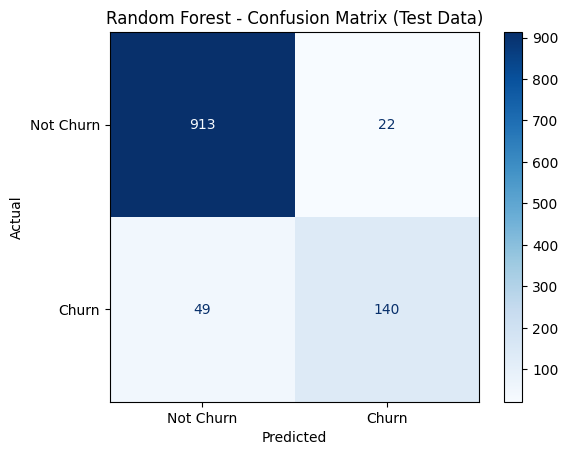

In [51]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Churn', 'Churn'])
disp.plot(cmap="Blues")
plt.title("Random Forest - Confusion Matrix (Test Data)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Feature Importance Bar Chart

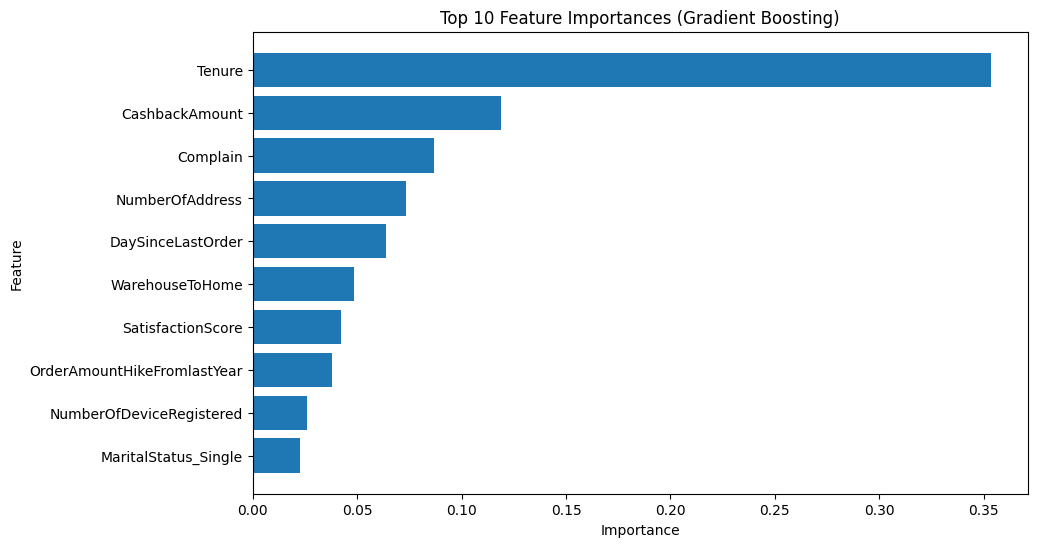

In [52]:
# Bar Chart of Feature Importance
plt.figure(figsize=(10,6))
plt.barh(gb_importance['Feature'].head(10), gb_importance['Importance'].head(10))
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances (Gradient Boosting)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


## Analysis

### Model Performance

Accuracy: 0.937

Class = 0 (Non-Churn)
- Recall = 0.98
- The model rarely misclassifies customers who stay.

Class = 1 (Churn)
- Recall = 0.74
- The model correctly identifies most customers who are at risk of churning.

### Interpretation

Overall Model Performance
- The Boosted Tree model performs very well overall, achieving 93.7% accuracy on the test set.
- It accurately classifies non-churn customers, with strong performance and minimal misclassification.
- Importantly, its ability to identify churners is strong, correctly capturing a large share of customers who actually leave.
- This makes the model highly useful for real business decisions, providing reliable signals for targeted retention strategies.
- Train Accuracy = 98.62%, Test Accuracy = 93.68%; this gap indicates moderate overfitting, but the model still generalizes effectively and delivers strong predictive performance on unseen data.

### Feature Importance

Top Predictors of Churn:
- Tenure is by far the strongest predictor; customers with shorter tenure are much more likely to churn.
- CashbackAmount is highly influential, showing that customers are sensitive to financial incentives.
- Complain, NumberOfAddress, and DaySinceLastOrder capture behavioral and satisfaction-related signals that strongly correlate with churn.

Other Influential Predictors:
- WarehouseToHome distance, OrderAmountHikeFromlastYear, SatisfactionScore, and NumberOfDeviceRegistered each contribute smaller but meaningful predictive value.
- MaritalStatus_Single has a minor effect but still helps the model differentiate customer profiles.

Overall Interpretation:
- Churn risk is shaped by a mix of loyalty indicators (Tenure), customer behavior (Complaints, Order activity, Addresses), and value/convenience factors (Cashback, Delivery distance).
- Together, these features help the model distinguish between stable customers and those more likely to leave.

In [53]:
import pickle

# Save the model
with open("5_Boosted_Tree", "wb") as file:
    pickle.dump('5_Boosted_Tree', file)